In [39]:
# we need it in all codes
import numpy as np 
import math
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from PIL import Image
import scipy.sparse
from scipy.sparse import csr_matrix
# see functions here
# https://numpy.org/doc/stable/reference/generated/numpy.exp.html
# https://numpy.org/doc/stable/reference/routines.array-manipulation.html
#

# basic vector and matrix operations
# general principle: we do not have to write functions for everything
# moreover, built-in vectorized operations are rather fast


# THE SAME PROBLEM AS IN LEC.10 BUT A SELF-MADE STOCHASTIC OPTIMIZER 

[ 8.91        8.92382952  8.93766887 ... 94.47343079 94.51671048
 94.56      ]


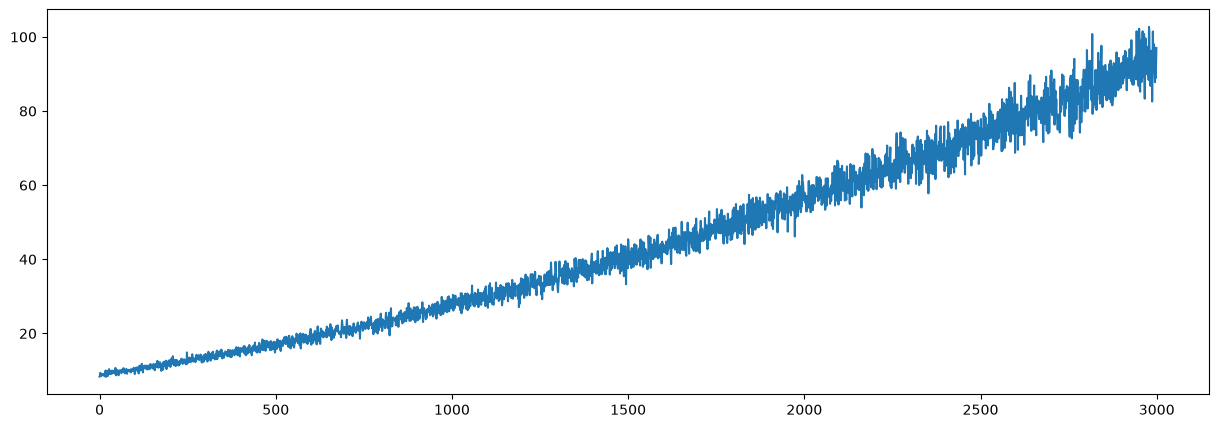

In [40]:
# Real model  
# s (t) = g * t**2 /2  + v0 * t
# MEASURED QUANTITIES: s: distance(output)   t: time (input);  
# PARAMETERS TO FIND:    v0: initial speed;  g: gravitational constant

# Generating data:
# Time:  
t_all = np.linspace(1,4,3000)  
# parameters for testing
v0 = 4 
g = 9.82
# analytic result distance
sol_a = g * t_all**2 /2  + v0 * t_all
# random  multiplyer
r_mult = np.random.normal(1,0.05, 3000)
# pointwise multiplication: observed data for distance
s_obs = r_mult * sol_a
# now we have 3000 observation data

plt.rcParams["figure.figsize"] = (15,5)
print(sol_a)
plt.plot(s_obs)
# In which norm should we measure their deviation?
# Measure the distance in averaged square norm : 

# (g * t_all[0]**2 /2  + v0 * t_all[0] - s_obs [0])**2  + (g * t_all[1]**2 /2  + v0 * t_all[1] - s_obs [1])**2  +
#  ...   + (g * t_all[2999]**2 /2  + v0 * t_all[2999] - s_obs [2999])**2

In [41]:
# Now we have to compute manually (later on, Python should do that) 
# the gradient.
# First w.r.t.  the variable  g
#
# grad_loss [0] = 
# 2*(g * t_all[0]**2 /2  + v0 * t_all[0] - s_obs [0])* t_all[0]**2 /2  + 
# 2*(g * t_all[1]**2 /2  + v0 * t_all[1] - s_obs [1])* t_all[1]**2 /2  +
#  ...   +        
# 2*(g * t_all[2999]**2 /2  + v0 * t_all[2999] - s_obs [2999])**2
#
# then w.r.t. the variable  v0
# grad_loss [1] = 
# 2*(g * t_all[0]**2 /2  + v0 * t_all[0] - s_obs [0])* t_all[0]  + 
# 2*(g * t_all[1]**2 /2  + v0 * t_all[1] - s_obs [1])* t_all[1]  +
#  ...   +        
# 2*(g * t_all[2999]**2 /2  + v0 * t_all[2999] - s_obs [2999])*t_all[2999]

# Construct now a stochastic gradient of size 5.

# These will be the indices
ind = np.random.randint(0, len(t_all), size=5)
print(ind)

# This is the gradient itself
grad_st = np.array([0, 0])
for j in ind:
    grad_st[0] = grad_st[0] + 2*(g * t_all[j]**2 /2  + v0 * t_all[j] - s_obs [j])* t_all[j]**2 /2 
    grad_st[1] = grad_st[1] + 2*(g * t_all[j]**2 /2  + v0 * t_all[j] - s_obs [j])* t_all[j]
print(grad_st)

[2474 2862  408  615  408]
[68 37]


[10.42772083  3.72030175]
[10.40725342  3.70678442]
[10.39358744  3.69763394]
[10.38827444  3.69074802]
[10.39670635  3.69413189]
[10.27419403  3.61762251]
[10.15508647  3.54881694]
[10.10616099  3.5252693 ]
[10.09588399  3.51630283]
[10.2435488   3.59689922]
[10.23233836  3.58271101]
[10.25468427  3.60264793]
[10.13059025  3.5250677 ]
[10.05846641  3.49490009]
[10.06599641  3.50143962]
[10.08303834  3.51128411]
[9.98632445 3.45322154]
[9.98473755 3.45774967]
[10.02818689  3.49397697]
[9.98861123 3.47121315]
[10.01254557  3.48980374]
[9.97433082 3.46104031]
[10.03175226  3.508337  ]
[10.03880244  3.51961476]
[10.08787375  3.55193511]
[10.0026511   3.50701279]
[10.04433192  3.53167963]
[9.99781281 3.5100731 ]
[10.05316646  3.55349208]
[10.06392916  3.56348137]
[10.08561223  3.57336697]
[10.11104816  3.58894512]
[10.15685376  3.61333863]
[10.2238501   3.65801725]
[10.21169071  3.65090857]
[10.16297054  3.61939754]
[10.15974542  3.61697299]
[10.11895347  3.59899404]
[10.15902937  3.627384

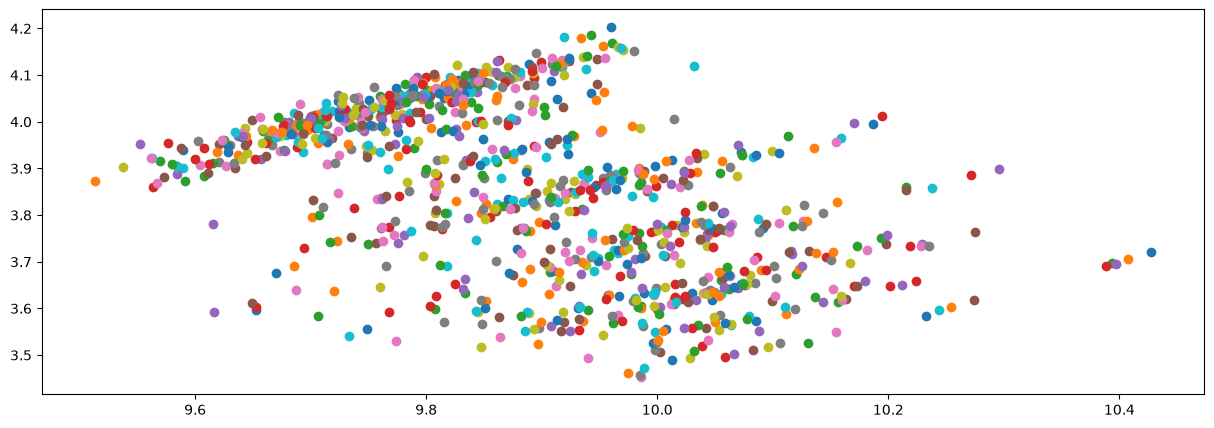

In [42]:
# We can now run the gradient descent with this 

# Starting value
param = np.array([10.4,3.7])
# Set learning rate
alpha = 0.001

for k in range(1000):
    ind = np.random.randint(0, len(t_all), size=5)
    # compute tthe stochastic gradient as above
    grad_st = np.array([0.0, 0.0])
    for j in ind:
        grad_st[0] = grad_st[0] + 2*(param[0] * t_all[j]**2 /2  + param[1] * t_all[j] - s_obs [j])* t_all[j]**2 /2 
        grad_st[1] = grad_st[1] + 2*(param[0] * t_all[j]**2 /2  + param[1] * t_all[j] - s_obs [j])* t_all[j]
# take one step with this        
    param = param - alpha * grad_st   
    print(param)
    plt.plot(param[0], param[1], 'o')

In [43]:
# Play with this: change the number of the sample, the learning parameter and the iteration number.